# Classification Ages: Young vs Old Battery

> **Authors:** Davide Corso, Marco Soldani  
> **Context:** Analysis of Galvanostatic Electrochemical Impedance Spectroscopy (GEIS) data on Lithium-Ion batteries (LiCoO₂).

>
**Expected result:** Given a Nyquist diagram at a certain SOC (chosen by the user or randomly), classify whether the battery is new (Epoch 0–2) or old (Epoch 3–4).

---

### Difference with the previous notebook (1: LOO)

| | NB1: Leave-One-Out | **NB2: Classification Ages** |
|---|---|---|
| **Type** | Regression | **Classification** |
| **Target** | Z_real, Z_imag | **Young / Old** |
| **Input** | Epoch, Temp, SOC, Freq | **Temp, Freq, Z_real, Z_imag** |
| **Challenge** | Predict one graph | **Distinguish aging from the shape of the Nyquist plot** |


> In this task, impedance is the **input** (not the target): the model must infer from the appearance of the Nyquist plot whether the battery is young or old.

# 1. Setup

In [2]:
import sys
assert sys.version_info >= (3, 5), "Python 3.5+ is required"

# --- STANDARD LIBRARIES ---
import warnings
import time

# --- SCIENTIFIC LIBRARIES ---
import numpy as np
import pandas as pd
import scipy.io

# --- VISUALIZATION ---
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns

# --- MACHINE LEARNING ---
from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    GridSearchCV,
    StratifiedKFold
)
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    BaggingClassifier,
    ExtraTreesClassifier
)
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)

# --- CONFIGURATION ---
warnings.filterwarnings("ignore")

plt.style.use("seaborn-v0_8-whitegrid")
mpl.rc("axes", labelsize=13)
mpl.rc("xtick", labelsize=11)
mpl.rc("ytick", labelsize=11)
mpl.rc("legend", fontsize=10)
mpl.rc("figure", dpi=120)

# --- CONSTANTS ---
TEMP_COLORS = {
    20.0: "#1b9e77",
    22.5: "#d95f02",
    25.0: "#7570b3",
    27.5: "#e7298a",
    30.0: "#66a61e",
    35.0: "#e6ab02",
    40.0: "#a6761d",
    47.5: "#666666",
}

EPOCH_LABELS = {
    0: "Epoch 0 (Fresh)",
    1: "Epoch 1",
    2: "Epoch 2",
    3: "Epoch 3",
    4: "Epoch 4 (Aged)",
}

SOC_MARKERS = {
    0: "o",
    1: "s",
    2: "^",
    3: "D",
    4: "v",
}

TEMPS_SORTED = sorted(TEMP_COLORS.keys())
EPOCHS = list(EPOCH_LABELS.keys())

CLASS_NAMES = ["Young (E0–E2)", "Old (E3–E4)"]
CLASS_COLORS = ["#2ecc71", "#e74c3c"]

# --- ENVIRONMENT INFO ---
def print_environment_info():
    import sklearn

    print("Setup completed")
    print(
        f"Python {sys.version_info.major}.{sys.version_info.minor} | "
        f"NumPy {np.__version__} | "
        f"Pandas {pd.__version__} | "
        f"Scikit-learn {sklearn.__version__}"
    )

print_environment_info()

Setup completed
Python 3.12 | NumPy 2.3.4 | Pandas 2.3.3 | Scikit-learn 1.8.0


# 2. Data Loading

In [3]:
# --- LOAD DATASET ---
from pathlib import Path

file_path = Path("..") / "data" / "raw" / "GEIS.mat"
mat_data = scipy.io.loadmat(file_path, squeeze_me=True, struct_as_record=False)

# --- TEMPERATURE MAPPING ---
TEMP_KEYS = {
    "GEIS_20": 20.0,
    "GEIS_22_5": 22.5,
    "GEIS_25": 25.0,
    "GEIS_27_5": 27.5,
    "GEIS_30": 30.0,
    "GEIS_35": 35.0,
    "GEIS_40": 40.0,
    "GEIS_47_5": 47.5,
}

# --- DATA EXTRACTION ---
records = []

for epoch in range(5):
    aging_struct = getattr(mat_data, f"Aging{epoch}", mat_data.get(f"Aging{epoch}"))
    
    for temp_key, temp_val in TEMP_KEYS.items():
        data = getattr(aging_struct, temp_key)
        
        for soc_idx, soc_data in enumerate(data):
            for row in soc_data:
                records.append({
                    "Epoch": epoch,
                    "Temperature": temp_val,
                    "SOC": soc_idx,
                    "Frequency": row[0],
                    "Z_real": row[1] * 1000,
                    "Z_imag": row[2] * 1000,
                })

df = pd.DataFrame(records)

# --- CLASSIFICATION LABELS ---
df["Age_class"] = (df["Epoch"] >= 3).astype(int)  # 0 = Young, 1 = Old
df["Age_label"] = df["Age_class"].map({0: "Young", 1: "Old"})

# --- DATASET SUMMARY ---
print(f"Dataset: {df.shape[0]:,} rows")

print("\n=== CLASS DISTRIBUTION ===")
young_count = (df["Age_class"] == 0).sum()
old_count = (df["Age_class"] == 1).sum()

print(f"Young (Epoch 0–2): {young_count:,} samples ({young_count / len(df) * 100:.1f}%)")
print(f"Old   (Epoch 3–4): {old_count:,} samples ({old_count / len(df) * 100:.1f}%)")

Dataset: 9,805 rows

=== CLASS DISTRIBUTION ===
Young (Epoch 0–2): 5,880 samples (60.0%)
Old   (Epoch 3–4): 3,925 samples (40.0%)


# 3. EDA: Young vs Old
Let’s analyze whether the classes are visually distinguishable in the Nyquist plots.

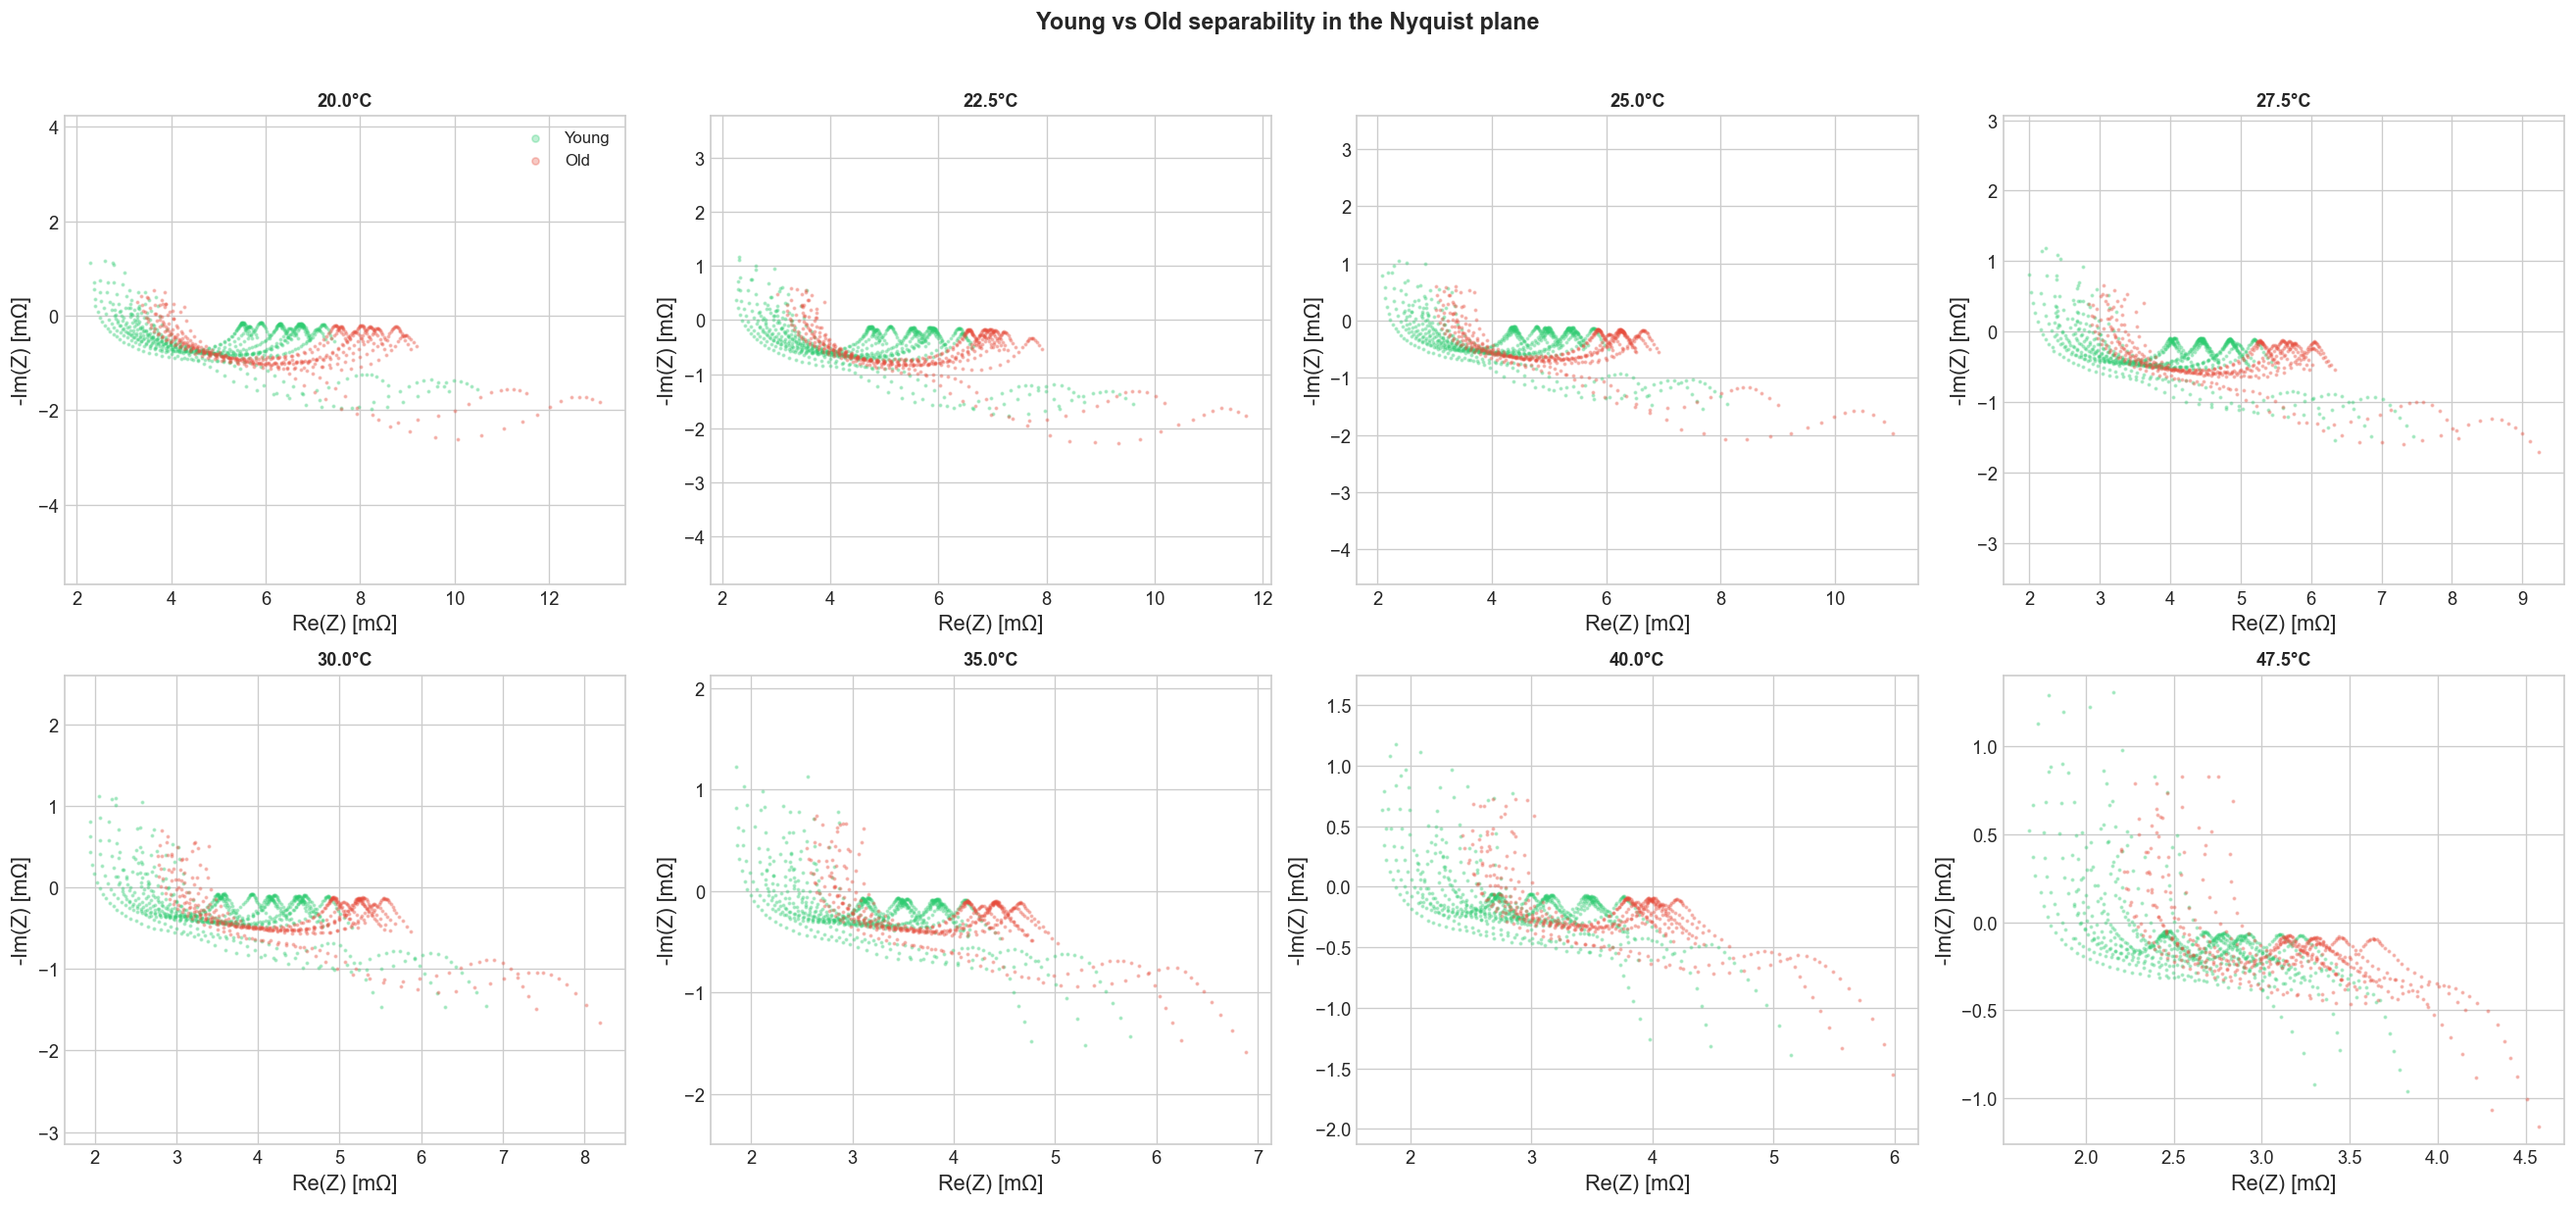

In [4]:
# --- NYQUIST PLOTS BY CLASS (YOUNG vs OLD) ---
# One example per temperature

fig, axes = plt.subplots(2, 4, figsize=(22, 10))
axes_flat = axes.flatten()

for idx, temp in enumerate(TEMPS_SORTED):
    ax = axes_flat[idx]
    subset = df[df["Temperature"] == temp]

    for cls, color, label in [
        (0, CLASS_COLORS[0], "Young"),
        (1, CLASS_COLORS[1], "Old"),
    ]:
        mask = subset["Age_class"] == cls

        ax.scatter(
            subset.loc[mask, "Z_real"],
            -subset.loc[mask, "Z_imag"],
            s=2,
            alpha=0.3,
            color=color,
            label=label,
        )

    ax.set_xlabel("Re(Z) [mΩ]")
    ax.set_ylabel("-Im(Z) [mΩ]")
    ax.set_title(f"{temp}°C", fontsize=11, fontweight="bold")
    ax.set_aspect("equal", adjustable="datalim")

    if idx == 0:
        ax.legend(markerscale=3, fontsize=10)

fig.suptitle(
    "Young vs Old separability in the Nyquist plane",
    fontsize=14,
    fontweight="bold",
    y=1.02,
)

plt.tight_layout()
plt.show()

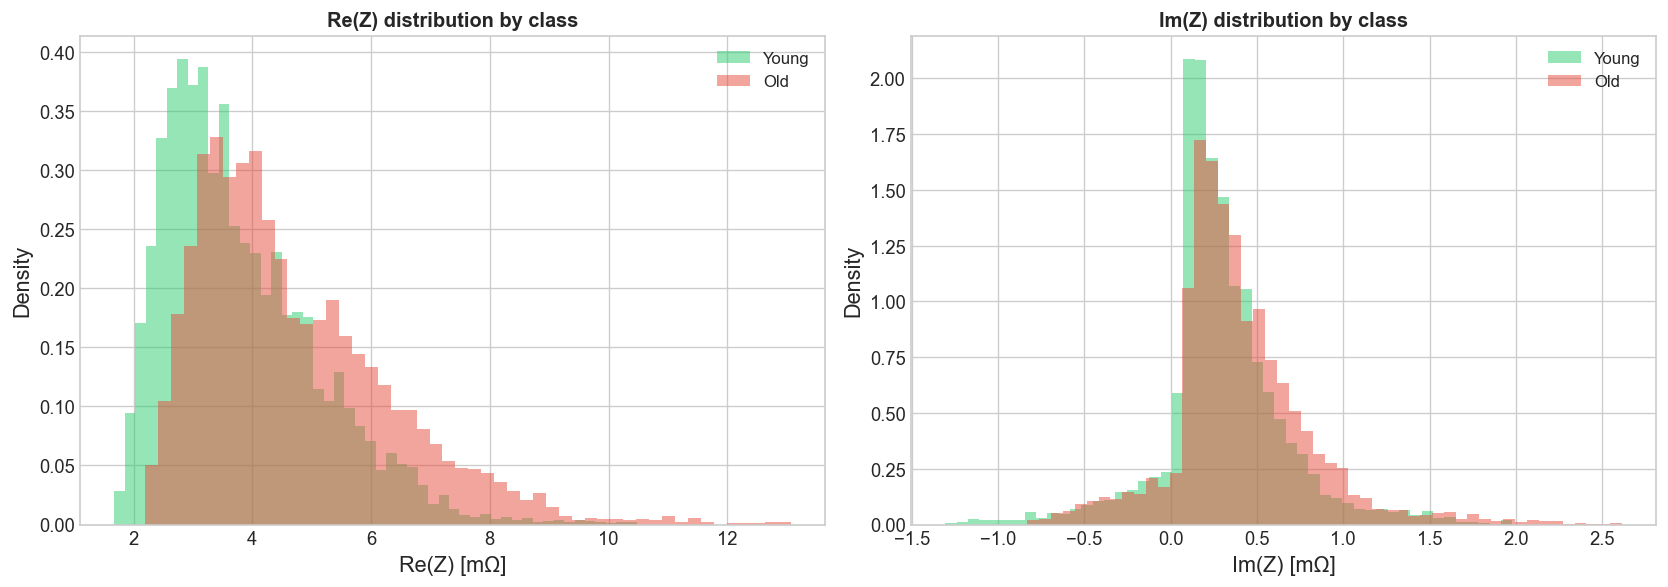

In [5]:
# --- DISTRIBUTION OF Re(Z) AND Im(Z) BY CLASS ---

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for cls, color, label in [
    (0, CLASS_COLORS[0], "Young"),
    (1, CLASS_COLORS[1], "Old"),
]:
    mask = df["Age_class"] == cls

    axes[0].hist(
        df.loc[mask, "Z_real"],
        bins=50,
        alpha=0.5,
        color=color,
        label=label,
        density=True,
    )

    axes[1].hist(
        df.loc[mask, "Z_imag"],
        bins=50,
        alpha=0.5,
        color=color,
        label=label,
        density=True,
    )

axes[0].set_xlabel("Re(Z) [mΩ]")
axes[0].set_ylabel("Density")
axes[0].set_title("Re(Z) distribution by class", fontweight="bold")
axes[0].legend()

axes[1].set_xlabel("Im(Z) [mΩ]")
axes[1].set_ylabel("Density")
axes[1].set_title("Im(Z) distribution by class", fontweight="bold")
axes[1].legend()

plt.tight_layout()
plt.show()

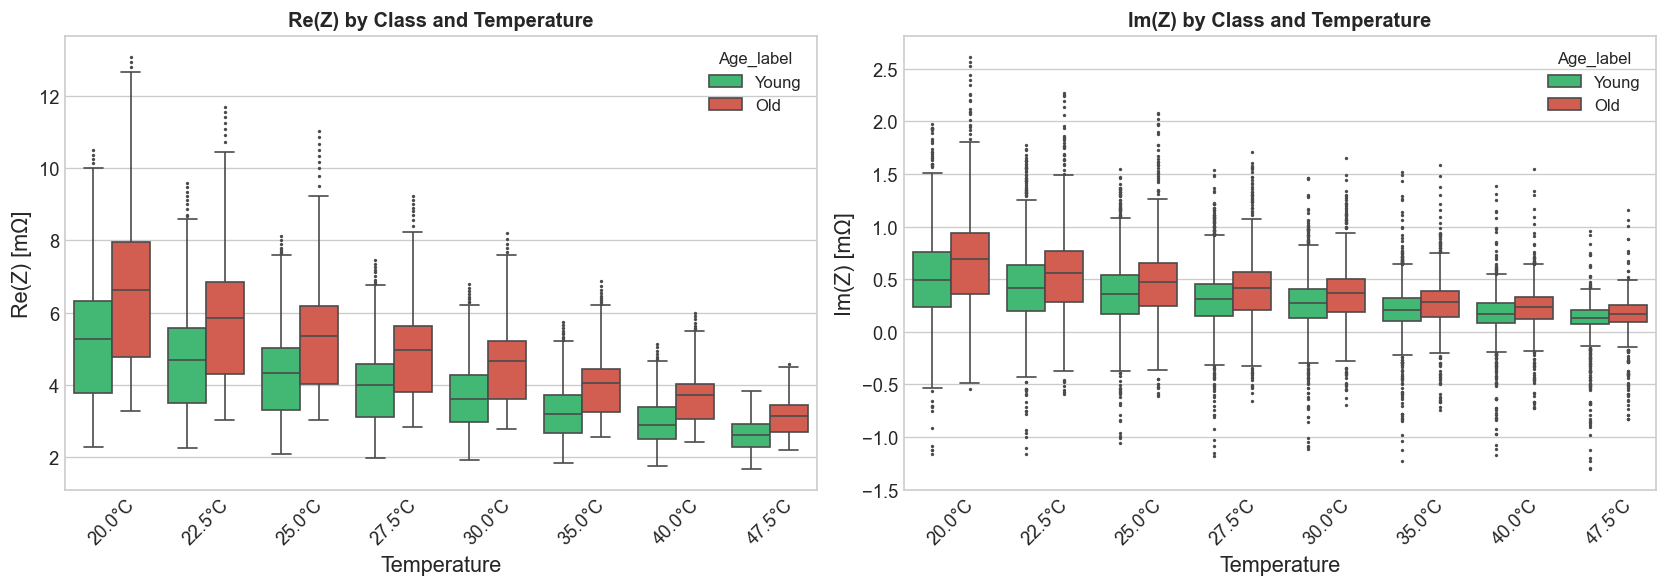

In [6]:
# --- BOX PLOTS BY CLASS AND TEMPERATURE ---

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df_plot = df.copy()
df_plot["Temp_str"] = df_plot["Temperature"].astype(str) + "°C"

sns.boxplot(
    data=df_plot,
    x="Temp_str",
    y="Z_real",
    hue="Age_label",
    palette={"Young": CLASS_COLORS[0], "Old": CLASS_COLORS[1]},
    ax=axes[0],
    fliersize=1,
)

axes[0].set_xlabel("Temperature")
axes[0].set_ylabel("Re(Z) [mΩ]")
axes[0].set_title("Re(Z) by Class and Temperature", fontweight="bold")
axes[0].tick_params(axis="x", rotation=45)

sns.boxplot(
    data=df_plot,
    x="Temp_str",
    y="Z_imag",
    hue="Age_label",
    palette={"Young": CLASS_COLORS[0], "Old": CLASS_COLORS[1]},
    ax=axes[1],
    fliersize=1,
)

axes[1].set_xlabel("Temperature")
axes[1].set_ylabel("Im(Z) [mΩ]")
axes[1].set_title("Im(Z) by Class and Temperature", fontweight="bold")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

# 4. SOC Selection

The user selects an SOC level (or randomly). The classifier will be trained and evaluated **only** on that SOC.

This simulates a real-world scenario: you measure impedance at a given SOC and want to determine whether the battery is old or new.

In [7]:
# ╔════════════════════════════════════════════════════════════╗
# ║  CONFIGURATION: Select SOC                                 ║
# ╚════════════════════════════════════════════════════════════╝

mode = "random"       # "random" or "manual"
MANUAL_SOC = 2        # Default, if mode="manual" specify SOC (0, 1, 2, 3, 4)

# ─────────────────────────────────────────────────────────────

available_socs = sorted(df["SOC"].unique())

if mode == "manual":
    assert MANUAL_SOC in available_socs, (
        f"Invalid SOC {MANUAL_SOC}. Available values: {available_socs}"
    )
    SELECTED_SOC = MANUAL_SOC
    print(f"MANUAL mode — Selected SOC: {SELECTED_SOC}")

elif mode == "random":
    np.random.seed(None)
    SELECTED_SOC = np.random.choice(available_socs)
    print(f"RANDOM mode — Selected SOC: {SELECTED_SOC}")

else:
    raise ValueError(f"Unknown mode '{mode}'.")

# --- FILTER DATA BY SOC ---
df_soc = df[df["SOC"] == SELECTED_SOC].copy()

# --- SUMMARY ---
print(f"\nTotal samples for SOC {SELECTED_SOC}: {len(df_soc):,}")

young_count = (df_soc["Age_class"] == 0).sum()
old_count = (df_soc["Age_class"] == 1).sum()

print(f"Young: {young_count} ({young_count / len(df_soc) * 100:.1f}%)")
print(f"Old:   {old_count} ({old_count / len(df_soc) * 100:.1f}%)")

RANDOM mode — Selected SOC: 4

Total samples for SOC 4: 1,961
Young: 1176 (60.0%)
Old:   785 (40.0%)


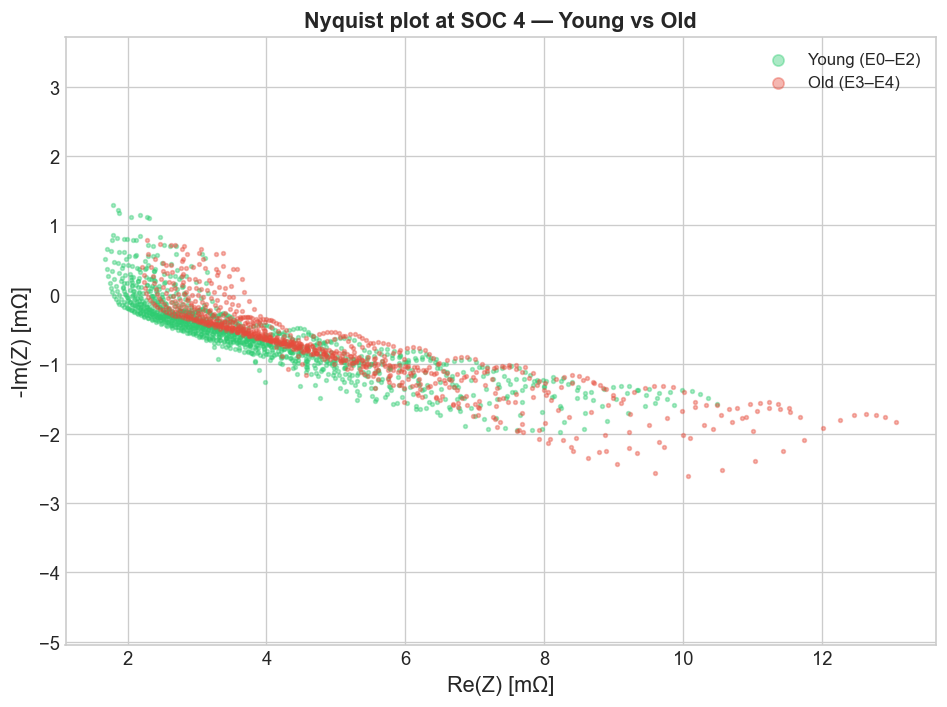

In [8]:
# --- NYQUIST PLOT FOR SELECTED SOC (COLORED BY CLASS) ---

fig, ax = plt.subplots(figsize=(8, 6))

for cls, color, label in [
    (0, CLASS_COLORS[0], "Young (E0–E2)"),
    (1, CLASS_COLORS[1], "Old (E3–E4)"),
]:
    mask = df_soc["Age_class"] == cls

    ax.scatter(
        df_soc.loc[mask, "Z_real"],
        -df_soc.loc[mask, "Z_imag"],
        s=5,
        alpha=0.4,
        color=color,
        label=label,
    )

ax.set_xlabel("Re(Z) [mΩ]")
ax.set_ylabel("-Im(Z) [mΩ]")
ax.set_title(
    f"Nyquist plot at SOC {SELECTED_SOC} — Young vs Old",
    fontsize=13,
    fontweight="bold",
)

ax.legend(markerscale=3)
ax.set_aspect("equal", adjustable="datalim")

plt.tight_layout()
plt.show()

# 5. Feature Engineering

The features are now the **impedance measurements** themselves, along with temperature and frequency.  

Epoch is not used as a feature (it is the variable from which the target is derived).

In [9]:
# --- FEATURE ENGINEERING FOR CLASSIFICATION ---

def build_classification_features(data):
    X = pd.DataFrame({
        "Temperature": data["Temperature"].values,
        "Frequency": data["Frequency"].values,
        "log_Freq": np.log10(data["Frequency"].values),
        "Z_real": data["Z_real"].values,
        "Z_imag": data["Z_imag"].values,
        "Z_magnitude": np.sqrt(
            data["Z_real"].values ** 2 + data["Z_imag"].values ** 2
        ),
        "Z_phase": np.arctan2(
            data["Z_imag"].values,
            data["Z_real"].values
        ),
        "inv_Temp": 1.0 / (data["Temperature"].values + 273.15),
        "Z_real_x_Temp": data["Z_real"].values * data["Temperature"].values,
        "sqrt_Freq": np.sqrt(data["Frequency"].values),
    })
    return X


# --- DATASET PREPARATION ---
X_all = build_classification_features(df_soc)
y_all = df_soc["Age_class"].values

# --- TRAIN / TEST SPLIT (STRATIFIED 80/20) ---
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_all,
    y_all,
    test_size=0.2,
    random_state=42,
    stratify=y_all,
)

# --- STANDARDIZATION ---
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test = scaler.transform(X_test_raw)

# --- SUMMARY ---
print(f"Features ({X_all.shape[1]}): {list(X_all.columns)}\n")

print(
    f"Training: {X_train.shape[0]} samples "
    f"(Young: {(y_train == 0).sum()}, Old: {(y_train == 1).sum()})"
)

print(
    f"Test:     {X_test.shape[0]} samples "
    f"(Young: {(y_test == 0).sum()}, Old: {(y_test == 1).sum()})"
)

Features (10): ['Temperature', 'Frequency', 'log_Freq', 'Z_real', 'Z_imag', 'Z_magnitude', 'Z_phase', 'inv_Temp', 'Z_real_x_Temp', 'sqrt_Freq']

Training: 1568 samples (Young: 940, Old: 628)
Test:     393 samples (Young: 236, Old: 157)


# 6. Multi-Model Training

Comparison between 6 classifiers:

| Model | Type |
|---|---|
| Logistic Regression | Linear |
| Random Forest | Ensemble (bagging) |
| Gradient Boosting | Ensemble (boosting) |
| Extra Trees | Ensemble (bagging) |
| K-Nearest Neighbors | Instance-based |
| SVM (RBF) | Kernel-based |

In [10]:
# --- MODEL DEFINITIONS ---

models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=42
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        max_depth=15,
        random_state=42,
        n_jobs=-1
    ),
    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=100,
        max_depth=5,
        learning_rate=0.1,
        random_state=42
    ),
    "Extra Trees": ExtraTreesClassifier(
        n_estimators=100,
        max_depth=15,
        random_state=42,
        n_jobs=-1
    ),
    "K-Nearest Neighbors": KNeighborsClassifier(
        n_neighbors=10,
        weights="distance"
    ),
    "SVM (RBF)": SVC(
        kernel="rbf",
        C=10.0,
        probability=True,
        random_state=42
    ),
}

# --- STORAGE ---
results = []
predictions = {}
probabilities = {}

# --- TRAINING HEADER ---
print(f"=== TRAINING — SOC Classification {SELECTED_SOC} ===\n")
print(f"{'Model':<25s} {'Accuracy':>9s} {'F1':>6s} {'AUC':>6s} {'Time':>7s}")
print("─" * 57)

# --- TRAINING LOOP ---
for name, model in models.items():

    t0 = time.time()
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    dt = time.time() - t0

    predictions[name] = y_pred

    # --- PROBABILITIES / SCORES ---
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test)[:, 1]
    else:
        y_proba = model.decision_function(X_test)

    probabilities[name] = y_proba

    # --- METRICS ---
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average="weighted")
    auc = roc_auc_score(y_test, y_proba)

    # --- CROSS VALIDATION ---
    cv = StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=42
    )

    cv_scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring="accuracy"
    )

    results.append({
        "Model": name,
        "Accuracy": acc,
        "F1": f1,
        "AUC": auc,
        "CV_mean": cv_scores.mean(),
        "CV_std": cv_scores.std(),
        "Time_s": dt,
    })

    print(f"{name:<25s} {acc:>9.4f} {f1:>6.4f} {auc:>6.4f} {dt:>6.1f}s")

# --- RESULTS SUMMARY ---
results_df = pd.DataFrame(results).sort_values("Accuracy", ascending=False)

best_model_name = results_df.iloc[0]["Model"]

print(
    f"\nBest model: {best_model_name} "
    f"(Acc={results_df.iloc[0]['Accuracy']:.4f})"
)

=== TRAINING — SOC Classification 4 ===

Model                      Accuracy     F1    AUC    Time
─────────────────────────────────────────────────────────
Logistic Regression          0.9186 0.9183 0.9683    0.0s
Random Forest                0.9669 0.9668 0.9960    0.1s
Gradient Boosting            0.9695 0.9694 0.9928    0.3s
Extra Trees                  0.9898 0.9898 0.9987    0.1s
K-Nearest Neighbors          0.9313 0.9313 0.9855    0.0s
SVM (RBF)                    0.9924 0.9924 0.9999    0.1s

Best model: SVM (RBF) (Acc=0.9924)


# 7. Model Comparison

In [11]:
# --- TABLE ---
print("=== RANKING ===\n")

display_df = results_df[
    ["Model", "Accuracy", "F1", "AUC", "CV_mean", "CV_std", "Time_s"]
].copy()

display_df.columns = [
    "Model",
    "Accuracy",
    "F1",
    "AUC",
    "CV_mean",
    "CV_std",
    "Time (s)",
]

print(display_df.to_string(index=False, float_format="{:.4f}".format))

=== RANKING ===

              Model  Accuracy     F1    AUC  CV_mean  CV_std  Time (s)
          SVM (RBF)    0.9924 0.9924 0.9999   0.9898  0.0089    0.0656
        Extra Trees    0.9898 0.9898 0.9987   0.9751  0.0150    0.0706
  Gradient Boosting    0.9695 0.9694 0.9928   0.9477  0.0124    0.2990
      Random Forest    0.9669 0.9668 0.9960   0.9502  0.0118    0.0883
K-Nearest Neighbors    0.9313 0.9313 0.9855   0.9247  0.0212    0.0020
Logistic Regression    0.9186 0.9183 0.9683   0.9330  0.0154    0.0084


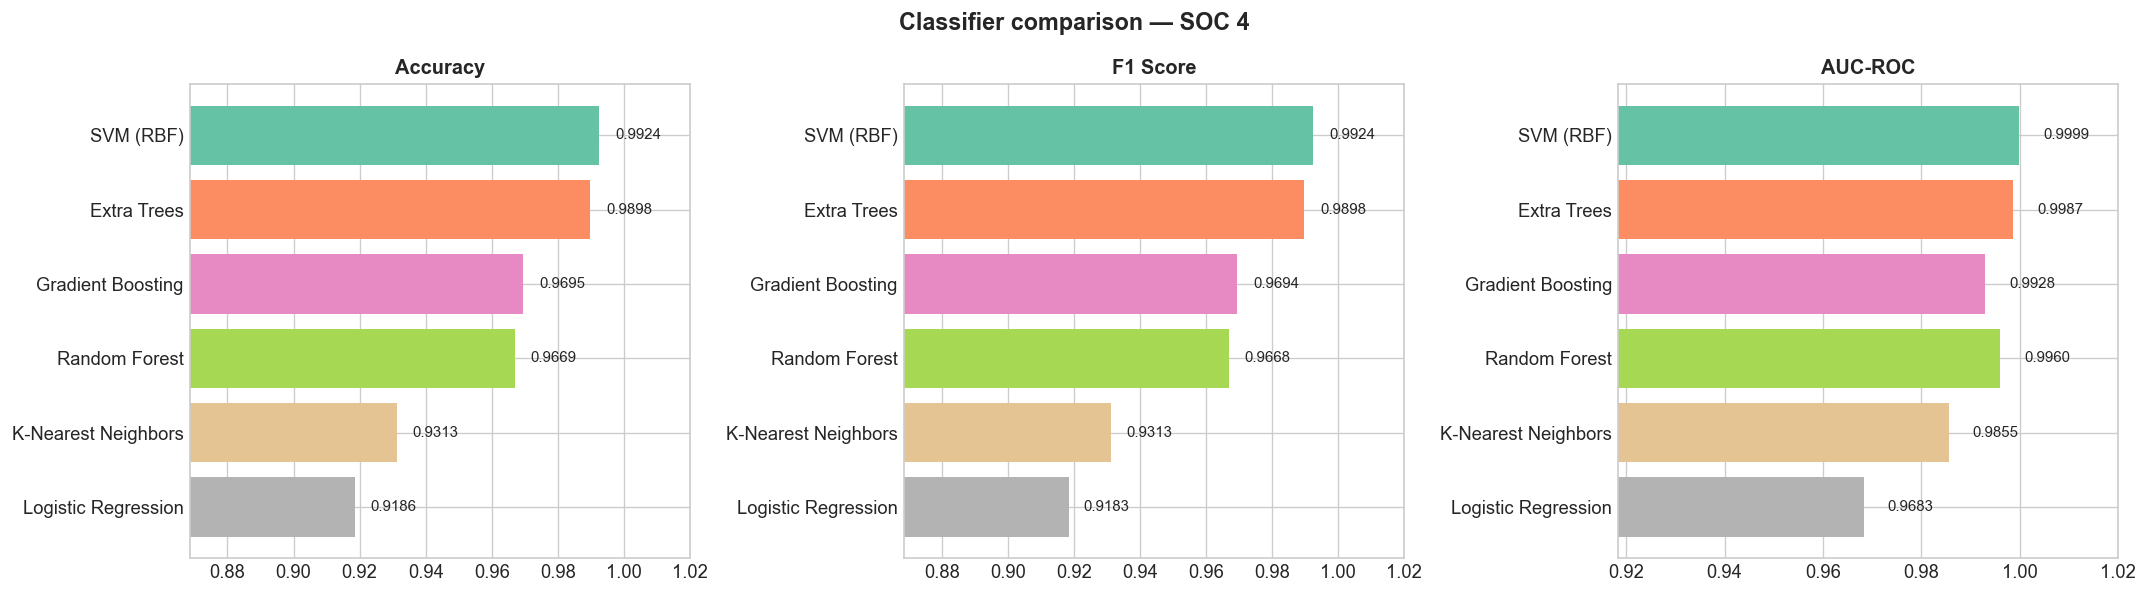

In [12]:
# --- METRICS COMPARISON PLOTS ---

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colors = plt.cm.Set2(np.linspace(0, 1, len(results_df)))

for ax, (col, title) in zip(
    axes,
    [("Accuracy", "Accuracy"), ("F1", "F1 Score"), ("AUC", "AUC-ROC")]
):
    bars = ax.barh(
        results_df["Model"].values,
        results_df[col].values,
        color=colors
    )

    ax.set_title(title, fontweight="bold")
    ax.invert_yaxis()
    ax.set_xlim([max(0, results_df[col].min() - 0.05), 1.02])

    for bar, v in zip(bars, results_df[col].values):
        ax.text(
            bar.get_width() * 1.005,
            bar.get_y() + bar.get_height() / 2,
            f"{v:.4f}",
            va="center",
            fontsize=9
        )

fig.suptitle(
    f"Classifier comparison — SOC {SELECTED_SOC}",
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

# 8. Confusion Matrix & ROC Curve

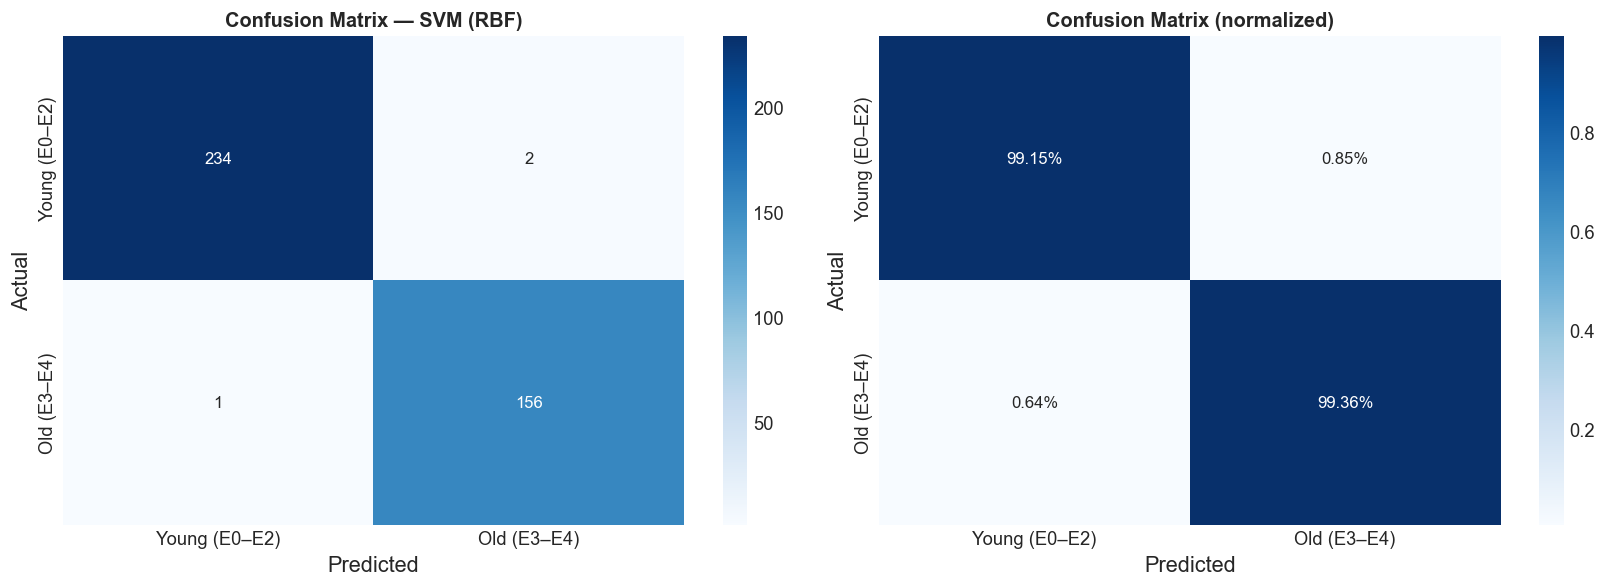


=== CLASSIFICATION REPORT (SVM (RBF)) ===

               precision    recall  f1-score   support

Young (E0–E2)       1.00      0.99      0.99       236
  Old (E3–E4)       0.99      0.99      0.99       157

     accuracy                           0.99       393
    macro avg       0.99      0.99      0.99       393
 weighted avg       0.99      0.99      0.99       393



In [13]:
# --- CONFUSION MATRIX FOR BEST MODEL ---

best_pred = predictions[best_model_name]
cm = confusion_matrix(y_test, best_pred)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- CONFUSION MATRIX (ABSOLUTE) ---
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    ax=axes[0],
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES,
)

axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")
axes[0].set_title(
    f"Confusion Matrix — {best_model_name}",
    fontweight="bold"
)

# --- CONFUSION MATRIX (NORMALIZED) ---
cm_norm = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis]

sns.heatmap(
    cm_norm,
    annot=True,
    fmt=".2%",
    cmap="Blues",
    ax=axes[1],
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES,
)

axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")
axes[1].set_title(
    "Confusion Matrix (normalized)",
    fontweight="bold"
)

plt.tight_layout()
plt.show()

# --- CLASSIFICATION REPORT ---
print(f"\n=== CLASSIFICATION REPORT ({best_model_name}) ===\n")

print(
    classification_report(
        y_test,
        best_pred,
        target_names=CLASS_NAMES
    )
)

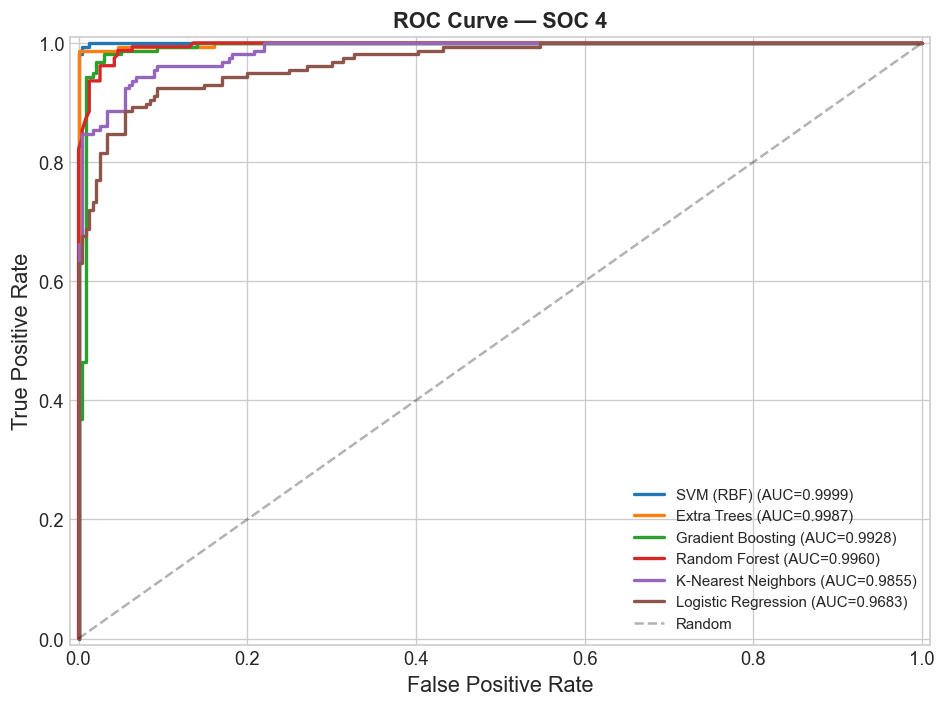

In [14]:
# --- ROC CURVE FOR ALL MODELS ---

fig, ax = plt.subplots(figsize=(8, 6))

for name in results_df["Model"].values:
    y_proba = probabilities[name]

    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc_val = roc_auc_score(y_test, y_proba)

    ax.plot(
        fpr,
        tpr,
        linewidth=2,
        label=f"{name} (AUC={auc_val:.4f})"
    )

# --- RANDOM BASELINE ---
ax.plot([0, 1], [0, 1], "k--", alpha=0.3, label="Random")

ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title(
    f"ROC Curve — SOC {SELECTED_SOC}",
    fontsize=13,
    fontweight="bold"
)

ax.legend(fontsize=9, loc="lower right")

ax.set_xlim([-0.01, 1.01])
ax.set_ylim([-0.01, 1.01])

plt.tight_layout()
plt.show()